# Diabetes Readmission RL Project
# Objectif : prédire et optimiser la réadmission des patients diabétiques (<30 jours)
# Approche : Reinforcement Learning Trees (RLT) – Zhu et al., 2015

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
sns.set(style="whitegrid")

## Business Understanding

In [2]:
print("Business Understanding")
print("BO1 — Réduire les réadmissions hospitalières")
print("    Identifier les patients à risque pour prévenir complications et coûts.")
print("BO2 — Optimiser la prise de décision clinique")
print("    Recommander des interventions adaptées pour diminuer les réadmissions.")

Business Understanding
BO1 — Réduire les réadmissions hospitalières
    Identifier les patients à risque pour prévenir complications et coûts.
BO2 — Optimiser la prise de décision clinique
    Recommander des interventions adaptées pour diminuer les réadmissions.


## Data Science Objectives

In [3]:
print("\nData Science Objectives")
print("DSO1 — Prédire la réadmission")
print("    Entrées : âge, sexe, race, hospitalisation, diagnostics, traitements.")
print("    Sortie : probabilité de réadmission <30 jours.")
print("DSO2 — Politique de décision séquentielle (RLT)")
print("    Optimiser actions hospitalières via Reinforcement Learning Trees.")
print("    Reward : réadmission évitée + coût + qualité soins.")
print("    → RLT = RL + Arbres de décision (Zhu, Zeng & Kosorok, 2015)")


Data Science Objectives
DSO1 — Prédire la réadmission
    Entrées : âge, sexe, race, hospitalisation, diagnostics, traitements.
    Sortie : probabilité de réadmission <30 jours.
DSO2 — Politique de décision séquentielle (RLT)
    Optimiser actions hospitalières via Reinforcement Learning Trees.
    Reward : réadmission évitée + coût + qualité soins.
    → RLT = RL + Arbres de décision (Zhu, Zeng & Kosorok, 2015)


## Data Understanding

In [7]:
print("\nData Understanding")

# CORRIGÉ : Chemin Windows avec raw string (r"") ou double backslash (\\)
data_path = r"C:\Users\mahab\Downloads\diabetes+130-us+hospitals+for+years+1999-2008\diabetic_data.csv"
df = pd.read_csv(data_path)

print("Dimensions du dataset :", df.shape)
print("Colonnes :", df.columns.tolist())
df.head()


Data Understanding
Dimensions du dataset : (101766, 50)
Colonnes : ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Distribution readmission :
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


C:\Users\mahab\AppData\Local\Temp\ipykernel_24980\3290360901.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette="viridis")


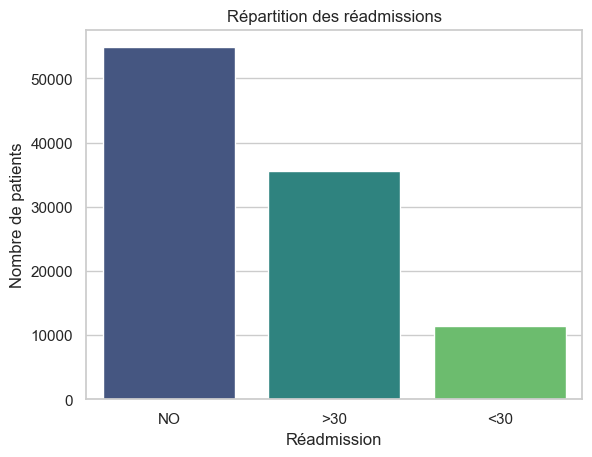

In [8]:
print("\nDistribution readmission :")
print(df['readmitted'].value_counts())
sns.countplot(x='readmitted', data=df, palette="viridis")
plt.title("Répartition des réadmissions")
plt.xlabel("Réadmission")
plt.ylabel("Nombre de patients")
plt.show()

## Data Preparation

In [9]:
df_prep = df.copy()
df_prep = df_prep.replace("?", np.nan)

# Encodage
le_dict = {}
for col in df_prep.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    le_dict[col] = le

# Imputation
df_prep = df_prep.fillna(df_prep.median())

# Target binaire
df_prep['readmitted'] = (df_prep['readmitted'] == 1).astype(int)  # <30 = 1

# Supprimer IDs
df_prep = df_prep.drop(['encounter_id', 'patient_nbr'], axis=1, errors='ignore')

df_prep.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2,0,0,9,6,25,1,1,17,37,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,9,1,1,7,3,17,72,...,0,3,1,0,0,0,0,0,1,1
2,0,0,2,9,1,1,7,2,17,72,...,0,1,1,0,0,0,0,1,1,0
3,2,1,3,9,1,1,7,2,17,72,...,0,3,1,0,0,0,0,0,1,0
4,2,1,4,9,1,1,7,1,17,72,...,0,2,1,0,0,0,0,0,1,0


## Modeling : RLT (Reinforcement Learning Trees)

In [10]:
X = df_prep.drop('readmitted', axis=1).values
y = df_prep['readmitted'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

class SimpleRLT:
    def __init__(self, max_depth=5, mute_ratio=0.5):
        self.max_depth = max_depth
        self.mute_ratio = mute_ratio

    def fit(self, X, y):
        self.tree = self._build(X, y, depth=0, features=list(range(X.shape[1])))
        return self

    def _gini(self, y):
        p = np.bincount(y) / len(y)
        return 1 - np.sum(p**2)

    def _best_split(self, X, y, features):
        best_gain = -1
        best_f, best_v = None, None
        for f in np.random.choice(features, min(15, len(features)), replace=False):
            vals = np.unique(X[:, f])[[0, -1]]
            for v in vals:
                mask = X[:, f] <= v
                if len(y[mask]) < 2 or len(y[~mask]) < 2: continue
                gain = self._gini(y) - (len(y[mask])/len(y))*self._gini(y[mask]) - (len(y[~mask])/len(y))*self._gini(y[~mask])
                if gain > best_gain:
                    best_gain, best_f, best_v = gain, f, v
        return best_f, best_v

    def _build(self, X, y, depth, features):
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < 10:
            return np.bincount(y).argmax()

        f, v = self._best_split(X, y, features)
        if f is None:
            return np.bincount(y).argmax()

        mask = X[:, f] <= v
        muted = features if len(features) <= 10 else \
                [features[i] for i in np.random.choice(len(features), 
                 int(len(features) * (1 - self.mute_ratio)), replace=False)]

        left = self._build(X[mask], y[mask], depth+1, muted)
        right = self._build(X[~mask], y[~mask], depth+1, muted)
        return (f, v, left, right)

    def predict(self, X):
        def _pred(x, node):
            if not isinstance(node, tuple): return node
            f, v, left, right = node
            return _pred(x, left) if x[f] <= v else _pred(x, right)
        return [_pred(x, self.tree) for x in X]

# Entraînement forêt RLT
print("Entraînement RLT (20 arbres)...")
rlt_preds = []
for i in range(20):
    idx = np.random.choice(len(X_train), len(X_train), replace=True)
    tree = SimpleRLT()
    tree.fit(X_train[idx], y_train[idx])
    rlt_preds.append(tree.predict(X_test))
    if (i+1) % 5 == 0: print(f"  → {i+1}/20")

y_rlt = np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, np.array(rlt_preds))
acc_rlt = accuracy_score(y_test, y_rlt)
f1_rlt = f1_score(y_test, y_rlt)

Entraînement RLT (20 arbres)...
  → 5/20
  → 10/20
  → 15/20
  → 20/20


## Évaluation

Accuracy RLT : 0.651
F1-score RLT : 0.002


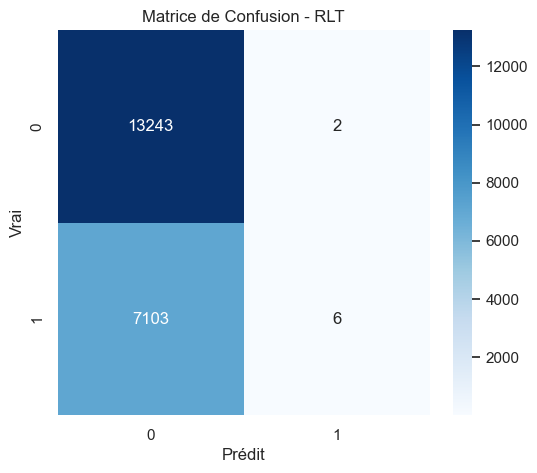

In [11]:
print(f"Accuracy RLT : {acc_rlt:.3f}")
print(f"F1-score RLT : {f1_rlt:.3f}")

cm = confusion_matrix(y_test, y_rlt)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion - RLT")
plt.xlabel("Prédit"); plt.ylabel("Vrai")
plt.show()